# 05 — Leakage-safe condition decoding across PC counts
## T15 attempted vocalized speech vs passive listening

Notebook 04 fitted one descriptive PCA to all 308 trials so they could be displayed in one common 3D figure. That is appropriate for an exploratory visualization, but those global PC scores must **not** be reused to estimate held-out decoding performance: the test trials helped define the axes.

This notebook answers the follow-up question correctly: does decoding improve with `1, 2, 3, 5, 10, or 20` PCs when scaling, PCA, and classification are refitted using training trials only?

## The no-leakage rule

For every held-out recording block:

```text
four training blocks                         one untouched test block
        │                                                │
        ├─ fit StandardScaler                            │
        ├─ fit PCA (up to 20 PCs)                        │
        ├─ fit logistic classifier on first k PCs        │
        │                                                │
        └──────── transform + predict only ──────────────┘
```

The six fixed-PC curves are useful model-comparison diagnostics. Choosing the best point and reporting that same curve would still be optimistic, so a second **nested CV** uses inner held-out blocks to choose `k` and reports performance only on the untouched outer block.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Run this notebook from the repository root or notebooks directory.')
sys.path.insert(0, str(ROOT / 'src'))

from kunz_speech_geometry.config import load_config
from kunz_speech_geometry.decoding import (
    fixed_pc_block_cv,
    flatten_trial_epochs,
    nested_pc_block_cv,
)
from kunz_speech_geometry.io import load_interleaved_mat
from kunz_speech_geometry.preprocess import smooth_and_baseline

config_path = Path(os.environ.get(
    'KUNZ_CONFIG', ROOT / 'configs' / 't15_interleaved_binnedtx.yaml'
))
if not config_path.is_absolute():
    config_path = ROOT / config_path
config = load_config(config_path)
seed = int(config['project']['random_seed'])
pc_candidates = [1, 2, 3, 5, 10, 20]
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})
print(f'Configuration: {config_path.relative_to(ROOT)}')
print(f'PC candidates: {pc_candidates}')

Configuration: configs/t15_interleaved_binnedtx.yaml
PC candidates: [1, 2, 3, 5, 10, 20]


## 1. Load the same real T15 trials and construct raw 3,200-value vectors

The loader's block centering is performed separately within each block; smoothing and baseline subtraction are performed separately within each trial. We then flatten the fixed half-open `[0, 500)` ms window. Importantly, no global standardization or PCA is run here.

In [2]:
mat_path = ROOT / config['dataset']['mat_path']
if not mat_path.is_file():
    raise FileNotFoundError(
        f'Missing {mat_path}. Run: python3 scripts/reproduce.py --data-only'
    )
dataset = load_interleaved_mat(
    mat_path,
    feature=config['dataset']['feature'],
    channel_sets=config['dataset'].get('channel_sets'),
    epoch_ms=tuple(config['dataset']['epoch_ms']),
    block_center=config['dataset'].get('block_center', True),
).subset_conditions(config['dataset']['conditions']).validate()
pre = config['preprocessing']
processed = smooth_and_baseline(
    dataset,
    smoothing_sigma_ms=pre['smoothing_sigma_ms'],
    baseline_window_ms=pre['baseline_window_ms'],
    baseline_correct=pre['baseline_correct'],
)
window_start, window_stop = map(float, pre['analysis_window_ms'])
time_mask = (processed.time_ms >= window_start) & (processed.time_ms < window_stop)
vectors = flatten_trial_epochs(processed.rates, time_mask)
labels = processed.trials['condition'].to_numpy()
groups = processed.trials['block'].to_numpy()

print(f'raw CV input matrix [trial, time×channel]: {vectors.shape}')
print(f'blocks: {sorted(np.unique(groups))}')
print('No pooled scaler or pooled PCA has been fitted.')
assert vectors.shape == (308, 3200)

raw CV input matrix [trial, time×channel]: (308, 3200)
blocks: [3, 4, 5, 7, 8]
No pooled scaler or pooled PCA has been fitted.


In [3]:
block_balance = (
    processed.trials.groupby(['block', 'condition', 'word'])
    .size()
    .rename('n_trials')
    .reset_index()
)
display(block_balance.pivot_table(
    index=['block', 'word'], columns='condition', values='n_trials', fill_value=0
))
assert (block_balance.groupby(['block', 'word']).condition.nunique() == 2).all()
print('Every block contains both conditions for every word.')

condition     attempted_vocalized  passive_listening
block word                                          
3     ban                     2.0                2.0
      choice                  2.0                2.0
      day                     2.0                2.0
      feel                    2.0                2.0
      kite                    2.0                2.0
      though                  2.0                2.0
      were                    2.0                2.0
4     ban                     5.0                5.0
      choice                  5.0                5.0
      day                     5.0                5.0
      feel                    5.0                5.0
      kite                    5.0                5.0
      though                  5.0                5.0
      were                    5.0                5.0
5     ban                     5.0                5.0
      choice                  5.0                5.0
      day                     5.0                5.0
      feel                    5.0                5.0
      kite                    5.0                5.0
      though                  5.0                5.0
      were                    5.0                5.0
7     ban                     5.0                5.0
      choice                  5.0                5.0
      day                     5.0                5.0
      feel                    5.0                5.0
      kite                    5.0                5.0
      though                  5.0                5.0
      were                    5.0                5.0
8     ban                     5.0                5.0
      choice                  5.0                5.0
      day                     5.0                5.0
      feel                    5.0                5.0
      kite                    5.0                5.0
      though                  5.0                5.0
      were                    5.0                5.0

Every block contains both conditions for every word.


## 2. Fixed-PC comparison with leave-one-block-out CV

This curve refits the scaler, PCA, and logistic regression separately in each fold. All candidates in a fold use prefixes of the same training-only 20-PC basis, so they differ only in how many leading components reach the classifier. The metric is balanced accuracy; chance is 50%.

In [4]:
fixed = fixed_pc_block_cv(
    vectors, labels, groups,
    pc_candidates=pc_candidates,
    random_state=seed,
)
display(fixed.summary.style.format({
    'mean_block_balanced_accuracy': '{:.1%}',
    'std_block_balanced_accuracy': '{:.1%}',
    'pooled_balanced_accuracy': '{:.1%}',
}))

,n_components,mean_block_balanced_accuracy,std_block_balanced_accuracy,pooled_balanced_accuracy
0,1,86.0%,3.7%,86.0%
1,2,87.6%,4.2%,87.3%
2,3,86.1%,4.0%,85.7%
3,5,88.0%,6.0%,88.3%
4,10,91.3%,3.6%,91.6%
5,20,91.1%,3.1%,90.9%


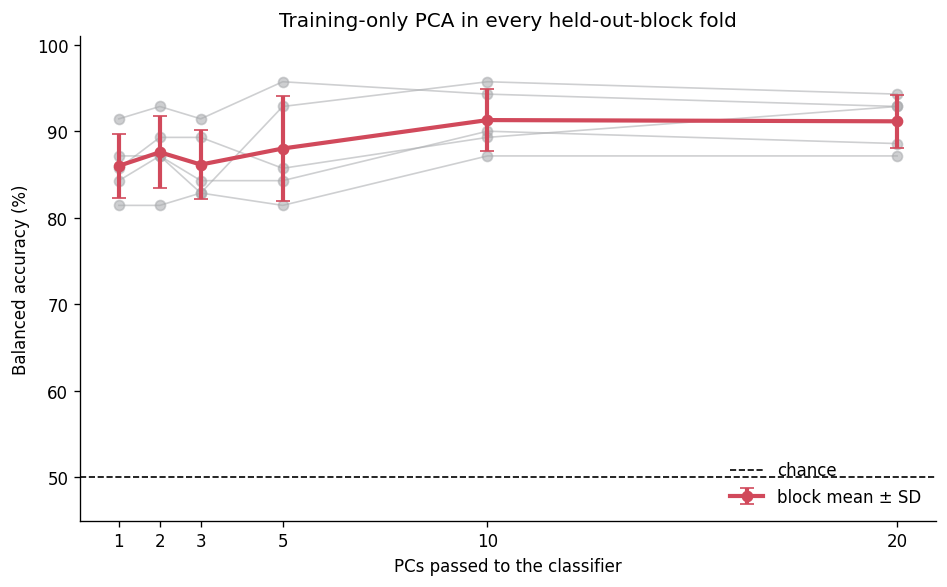

Generated figure: results/figures/t15_interleaved_binnedtx/mat_fixed_pc_cv_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for block, frame in fixed.fold_scores.groupby('test_group'):
    frame = frame.sort_values('n_components')
    ax.plot(
        frame['n_components'], 100 * frame['balanced_accuracy'],
        'o-', color='#A7A9AC', alpha=0.55, linewidth=1, label=f'block {block}',
    )
summary_curve = fixed.summary.sort_values('n_components')
ax.errorbar(
    summary_curve['n_components'],
    100 * summary_curve['mean_block_balanced_accuracy'],
    yerr=100 * summary_curve['std_block_balanced_accuracy'],
    fmt='o-', color='#D1495B', linewidth=2.5, capsize=4, label='block mean ± SD',
)
ax.axhline(50, color='black', linestyle='--', linewidth=1, label='chance')
ax.set(
    xlabel='PCs passed to the classifier',
    ylabel='Balanced accuracy (%)',
    title='Training-only PCA in every held-out-block fold',
    xticks=pc_candidates,
    ylim=(45, 101),
)
handles, legend_labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], legend_labels[-2:], frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
figure_dir = ROOT / config['outputs']['figure_dir']
figure_dir.mkdir(parents=True, exist_ok=True)
curve_path = figure_dir / 'mat_fixed_pc_cv_curve.png'
if config['outputs']['save_figures']:
    fig.savefig(curve_path, bbox_inches='tight', dpi=180)
plt.show()
print(f'Generated figure: {curve_path.relative_to(ROOT)}')

The fixed comparison shows whether additional PCs add useful held-out signal or mainly noise. However, selecting the highest point after seeing this graph and quoting that same score would favor the winner. Nested CV below separates selection from final evaluation.

## 3. Nested block CV

For each outer test block, the remaining four blocks run their own inner leave-one-block-out comparison. The PC count with the highest inner mean balanced accuracy is selected; ties prefer fewer PCs. The complete scaler–PCA–classifier chain is then refitted on all four outer-training blocks and evaluated once on the untouched outer block.

In [6]:
nested = nested_pc_block_cv(
    vectors, labels, groups,
    pc_candidates=pc_candidates,
    random_state=seed,
)
display(nested.fold_scores.style.format({
    'best_inner_mean_balanced_accuracy': '{:.1%}',
    'outer_balanced_accuracy': '{:.1%}',
}))
print(f'Nested pooled balanced accuracy: {nested.pooled_balanced_accuracy:.1%}')
print(f'Mean outer-block balanced accuracy: {nested.mean_block_balanced_accuracy:.1%}')

,test_group,n_train,n_test,selected_n_components,best_inner_mean_balanced_accuracy,outer_balanced_accuracy
0,3,280,28,20,90.7%,92.9%
1,4,238,70,10,88.8%,90.0%
2,5,238,70,20,88.4%,94.3%
3,7,238,70,10,89.8%,94.3%
4,8,238,70,20,92.3%,87.1%


Nested pooled balanced accuracy: 91.6%
Mean outer-block balanced accuracy: 91.7%


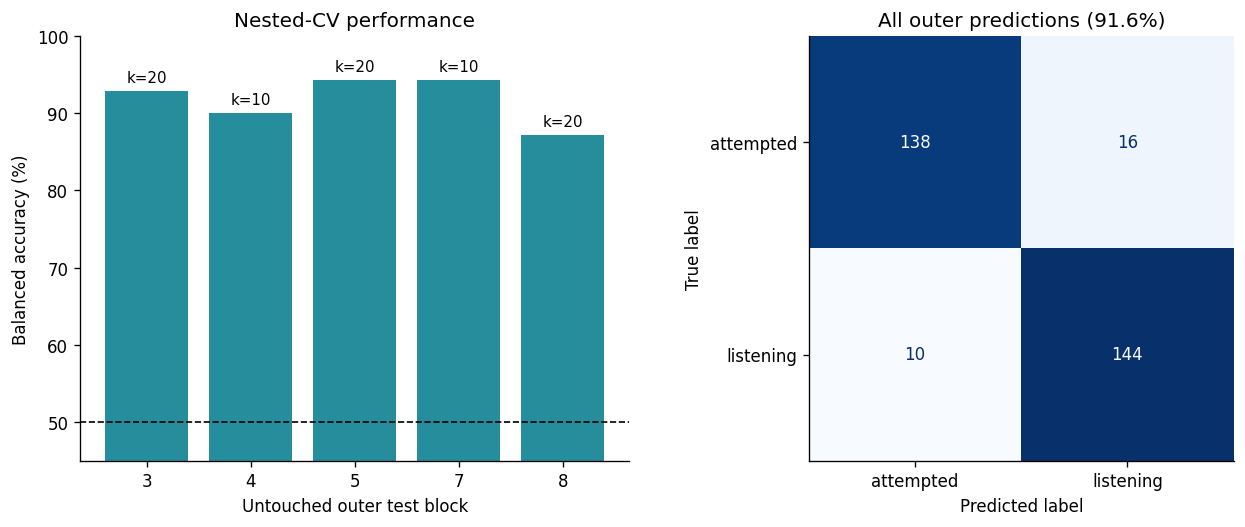

Generated figure: results/figures/t15_interleaved_binnedtx/mat_leakage_safe_pc_decoding.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
folds = nested.fold_scores.sort_values('test_group')
axes[0].bar(
    folds['test_group'].astype(str),
    100 * folds['outer_balanced_accuracy'],
    color='#00798C', alpha=0.85,
)
axes[0].axhline(50, color='black', linestyle='--', linewidth=1)
for index, row in folds.reset_index(drop=True).iterrows():
    axes[0].text(
        index, 100 * row['outer_balanced_accuracy'] + 1.2,
        f"k={int(row['selected_n_components'])}", ha='center', fontsize=9,
    )
axes[0].set(
    xlabel='Untouched outer test block', ylabel='Balanced accuracy (%)',
    title='Nested-CV performance', ylim=(45, 100),
)

display_labels = ['attempted_vocalized', 'passive_listening']
matrix = confusion_matrix(
    nested.predictions['true_label'], nested.predictions['predicted_label'],
    labels=display_labels,
)
ConfusionMatrixDisplay(matrix, display_labels=['attempted', 'listening']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title(f'All outer predictions ({nested.pooled_balanced_accuracy:.1%})')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

figure_dir = ROOT / config['outputs']['figure_dir']
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / 'mat_leakage_safe_pc_decoding.png'
if config['outputs']['save_figures']:
    fig.savefig(figure_path, bbox_inches='tight', dpi=180)
plt.show()
print(f'Generated figure: {figure_path.relative_to(ROOT)}')

## 4. Export fold-level evidence

The exported tables preserve every outer prediction, every selected PC count, and every inner model-selection curve. This makes it possible to audit the reported score without relying on the plot.

In [8]:
table_dir = ROOT / config['outputs']['table_dir'] / 'leakage_safe_decoding'
table_dir.mkdir(parents=True, exist_ok=True)
exports = {
    'fixed_pc_summary.csv': fixed.summary,
    'fixed_pc_fold_scores.csv': fixed.fold_scores,
    'fixed_pc_predictions.csv': fixed.predictions,
    'nested_outer_fold_scores.csv': nested.fold_scores,
    'nested_inner_scores.csv': nested.inner_scores,
    'nested_outer_predictions.csv': nested.predictions,
}
for filename, frame in exports.items():
    frame.to_csv(table_dir / filename, index=False)
print(f'Exported {len(exports)} audit tables under {table_dir.relative_to(ROOT)}')

Exported 6 audit tables under results/tables/t15_interleaved_binnedtx/leakage_safe_decoding


## Interpretation

- More than three PCs help here: the block-mean curve rises from about 86% with one PC to about 91% with 10 PCs. Twenty PCs do not improve the mean further, consistent with a plateau where extra dimensions add little useful held-out signal.
- The nested result estimates generalization to unseen recording blocks after PC-count selection. It is the appropriate headline decoding score; the maximum point in the fixed curve is a model-comparison diagnostic.
- This decodes **condition**, not words or inner speech content. Attempted production and passive listening differ in movement, auditory input, preparation, timing, and other task variables, so high accuracy does not identify a uniquely motor-intent representation.
- There are only five outer blocks, one of which is smaller than the others. The five fold scores should be shown rather than hiding uncertainty behind one pooled number.
- The analysis is from one participant and one session. Replication across participants, feature types, windows, and sessions remains necessary.

## Relationship to Notebook 04

Notebook 04 asks a descriptive geometry question and intentionally fits one global PCA so all 308 points share one display. This notebook asks a predictive generalization question and intentionally fits a different PCA inside every fold. Both are valid for their own purpose; only the fold-specific representations can support a held-out performance claim.